# Bunny graph diffusion


<div class="note"><span class="note-t">TL;DR</span>
<p>We scale the small graph walk's edge-local <code>PSWAP</code> rule up to heat flow on the Stanford bunny mesh. We then take a patch-sized Torx run and check its finite-sample agreement against the deterministic mean of the same ordered sweep.</p>
</div>

In this tutorial, we treat graph diffusion as heat spreading across a network.

We map each mesh edge to one `PSWAP` gate and run the resulting per-edge circuit on the surface of the Stanford bunny. Heat placed anywhere on the surface flows along edges toward cooler neighbors until the whole graph settles to one temperature.

Each vertex is a **probabilistic bit**. We place a single excitation (one hot pbit) and track its one-hot occupancy marginals: $x_i(t)$ is the probability the excitation sits at vertex $i$.

This becomes a circuit because heat diffusion factors edge by edge. The Laplacian $L = D - A$ splits into one symmetric two-node term per edge, so the propagator (the operator that evolves the state forward in time) can be approximated by ordered edge-local two-endpoint moves. One `PSWAP` per edge is then the natural circuit: the surface diffuses one biased coin flip at a time, with no global matrix update. The construction only needs the edge list, so any connected mesh works.

We start with the graph heat equation $\dot x = -Lx$ and derive the per-edge gate. We then place the excitation on one ear vertex and follow the front across the surface. At the end, we run the same ordered per-edge circuit in Torx on a small patch and check finite-sample agreement against its deterministic mean.

By the end, you'll be able to:

- derive one `PSWAP` from an edge Laplacian,
- run the bunny heat-flow sampler, and
- check a patch sampler against the deterministic mean of the same ordered product-formula sweep.

This is the mesh-scale version of [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb): the same `PSWAP`-per-edge primitive, now on a few hundred vertices.


## Setup

First we put the local `helpers` directory on the import path, then import Torx and NumPy.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
# Put shared notebook helpers on the import path.
sys.path.insert(0, str(HELPER_DIR))

In [2]:
from collections import deque

import numpy as np

from torx.psc import DiscretePCircuit, PSWAP

The diffusion routines and Stanford bunny mesh utilities live in the shared helper modules `examples/helpers/_graph_diffusion.py` and `examples/helpers/_stanford_bunny.py`.

In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
from _graph_diffusion import (
    _edge_swap_probability as shared_edge_swap_probability,
    apply_edge_product_formula,
    build_graph_generator,
    reference_heat_flow,
    sample_pswap_product_formula,
)
from _stanford_bunny import (
    largest_connected_mesh,
    load_ascii_ply,
    mesh_edges,
    save_torx_reference_figure,
    visible_source_vertex,
)

The notebook-specific plotting helpers set up the figure style, output paths, and the mesh file location.

In [4]:
import _plots_sampling as P_samp
import _plots_schematics as P_sch

apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
savefig = make_savefig(FIGURE_DIR)
MESH_PATH = ROOT / "assets" / "stanford_bunny" / "bun_zipper_res3.ply"
assert MESH_PATH.exists(), MESH_PATH

## Heat, the graph Laplacian, and one swap per edge

A mesh is a graph $G = (V, E)$: each vertex is a pbit, and each edge is a coupling. The **graph Laplacian** $L = D - A$, built from the degree matrix $D$ and the adjacency matrix $A$, is the discrete analogue of $-\nabla^2$, and heat on the graph obeys

$$
\dot x \;=\; -L\, x,
\qquad
x(t) \;=\; e^{-L t}\, x(0),
$$

so heat flows from hot vertices to cold neighbors. This is the master equation from [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb) with generator (the matrix of transition rates) $Q = -L$.

The Laplacian splits into one symmetric two-node block per edge, $L = \sum_{(i,j)\in E} L_{ij}$. **Lie-Trotter splitting** (Trotter 1959) rewrites the exact propagator as the limit of ordered per-edge products:

$$
x(t) \;=\; \lim_{N\to\infty}\Bigl(\underbrace{\textstyle\prod_{(i,j)\in E} e^{\Delta t\, Q_{ij}}}_{\vphantom{\big|}\text{ordered per-edge sweep}}\Bigr)^{N} x(0),
\qquad
\Delta t = t/N.
$$

At finite $N$, Torx executes each product as a sequential sweep over the edge list. Each isolated factor $e^{\Delta t\, Q_{ij}}$ is exactly a symmetric two-state swap, which is one `PSWAP` with $p = \tfrac12\bigl(1 - e^{-2\,\Delta t}\bigr)$ for the unit-rate (unweighted) mesh used here. The $O(t^2/N)$ factorization error comes entirely from overlapping edge blocks that share a vertex and do not commute.

The Torx sampler never forms the global propagator $e^{-Lt}$; the exact-reference cells below use dense linear algebra only for comparison. The initial state is a single excitation (one hot pbit), which `PSWAP` preserves, so the sampled one-hot occupancy marginal $x_i(t)$ is the probability the excitation sits at vertex $i$. That length-$|V|$ occupancy vector approximates the heat field $x(t)$.

## Heat spreading on the bunny

All the heat starts on one ear vertex and spreads from there.

We coarsen the Stanford bunny to a few hundred vertices with `decimate_mesh`. The coarsened mesh still looks like the bunny but is small enough for the diffusion front to move visibly across the surface. The mesh is the `bun_zipper_res3` reconstruction from the [Stanford 3D Scanning Repository](https://graphics.stanford.edu/data/3Dscanrep/) (Stanford Computer Graphics Laboratory).

The mass diffuses with one `PSWAP` per edge. Torx samples the field on the full mesh, so we first check Torx against the exact heat kernel at $t = 1.5$, a time short enough that 11 Trotter layers suffice.

The $t = 10$ and $t = 40$ panels are exact matrix-exponential references. Sampling those long-time fields with the PSWAP product formula would require many more Trotter layers than is practical here, so only the exact reference carries the longer-time spread.

Each panel is normalized to its own peak, so the front stays visible as the field decays toward the uniform equilibrium.

In [5]:
raw_vertices, raw_faces = load_ascii_ply(MESH_PATH)
full_vertices, full_faces = largest_connected_mesh(raw_vertices, raw_faces)

# Coarsen the mesh so the diffusion front propagates visibly across the surface
# within a readable time window.
TARGET_VERTICES = 400
vertices, faces = P_sch.decimate_mesh(full_vertices, full_faces, TARGET_VERTICES)
vertices, faces = largest_connected_mesh(vertices, faces)
edges = mesh_edges(faces)
source = visible_source_vertex(vertices)



In [6]:
assert len(full_vertices) == 1_887  # full largest connected component
assert 250 <= len(vertices) <= 600  # coarsened, still bunny-shaped
assert len(edges) >= len(vertices)  # connected surface mesh
# TORX_STEPS and the L2 gate below are tuned to this realized coarse mesh size.
# Changing the mesh or target size should come with retuned steps and thresholds.



In [7]:
print(f"full mesh:    {len(full_vertices)} vertices")
print(f"coarse mesh:  {len(vertices)} vertices, {len(faces)} faces, {len(edges)} edges")
print(f"source:       vertex {int(source)}")

full mesh:    1887 vertices
coarse mesh:  450 vertices, 932 faces, 1352 edges
source:       vertex 239


In [8]:
# Build the continuous-time generator for the unweighted mesh.
generator = build_graph_generator(len(vertices), edges, rate=1.0)
initial = np.zeros(len(vertices))
# Start with all heat concentrated at the chosen visible vertex.
initial[int(source)] = 1.0

TORX_TIME, TORX_STEPS, TORX_SAMPLES = 1.5, 11, 30_000
reference_times = [1.5, 10.0, 40.0]

Now we apply the `PSWAP` product formula on the full coarse mesh: we compute the per-edge swap probability and gate count, then the `apply_edge_product_formula` helper builds the one-gate-per-edge circuit, repeats it `TORX_STEPS` times, and estimates the occupancy field from Torx samples.

In [9]:
# This is nb02's per-edge construction scaled to the mesh: one PSWAP per edge,
# repeated TORX_STEPS times. The helper below rebuilds and samples exactly this.
p_edge = shared_edge_swap_probability(1.0, TORX_TIME, TORX_STEPS)
gate_applications = len(edges) * TORX_STEPS
print(
    f"{len(edges)} PSWAP gates x {TORX_STEPS} reps "
    f"= {gate_applications} gate applications; per-edge p = {p_edge:.4f}"
)

1352 PSWAP gates x 11 reps = 14872 gate applications; per-edge p = 0.1193


In [10]:
torx_field = apply_edge_product_formula(
    initial,
    edges,
    steps=TORX_STEPS,
    total_time=TORX_TIME,
    rate=1.0,
    num_samples=TORX_SAMPLES,
    seed=17,
)

In [11]:
# Exact heat-kernel values provide the deterministic comparison.
exact_fields = [reference_heat_flow(initial, generator, t) for t in reference_times]


def surface_fraction(field):
    """Fraction of vertices carrying more than 15% of the peak heat."""
    return float(np.mean(field > 0.15 * field.max()))




In [12]:
torx_l2 = float(np.linalg.norm(torx_field - exact_fields[0]))
mc_std_per_vertex = 0.5 / np.sqrt(TORX_SAMPLES)
mc_l2_component_bound = np.sqrt(len(vertices)) * mc_std_per_vertex
np.testing.assert_allclose(torx_field.sum(), 1.0, atol=5e-3)
assert torx_l2 < 0.04, f"torx vs exact L2 {torx_l2:.4f} >= 0.04"
assert exact_fields[0].max() > exact_fields[-1].max()
assert surface_fraction(exact_fields[-1]) > surface_fraction(exact_fields[0])



In [13]:
print("field            peak     vertices > 15% of peak")
print(
    f"torx  t={TORX_TIME:<4g}     {torx_field.max():.3f}        {surface_fraction(torx_field):.0%}"
)
for t, h in zip(reference_times, exact_fields, strict=True):
    print(f"exact t={t:<4g}     {h.max():.3f}        {surface_fraction(h):.0%}")
print(
    f"\ntorx vs exact at t={TORX_TIME:g}: L2 = {torx_l2:.4f} over {len(vertices)} vertices"
)
print(
    f"MC std <= {mc_std_per_vertex:.4f} per vertex; "
    f"conservative L2 scale <= {mc_l2_component_bound:.4f}"
)

field            peak     vertices > 15% of peak
torx  t=1.5      0.037        9%
exact t=1.5      0.037        9%
exact t=10       0.017        27%
exact t=40       0.004        100%

torx vs exact at t=1.5: L2 = 0.0160 over 450 vertices
MC std <= 0.0029 per vertex; conservative L2 scale <= 0.0612


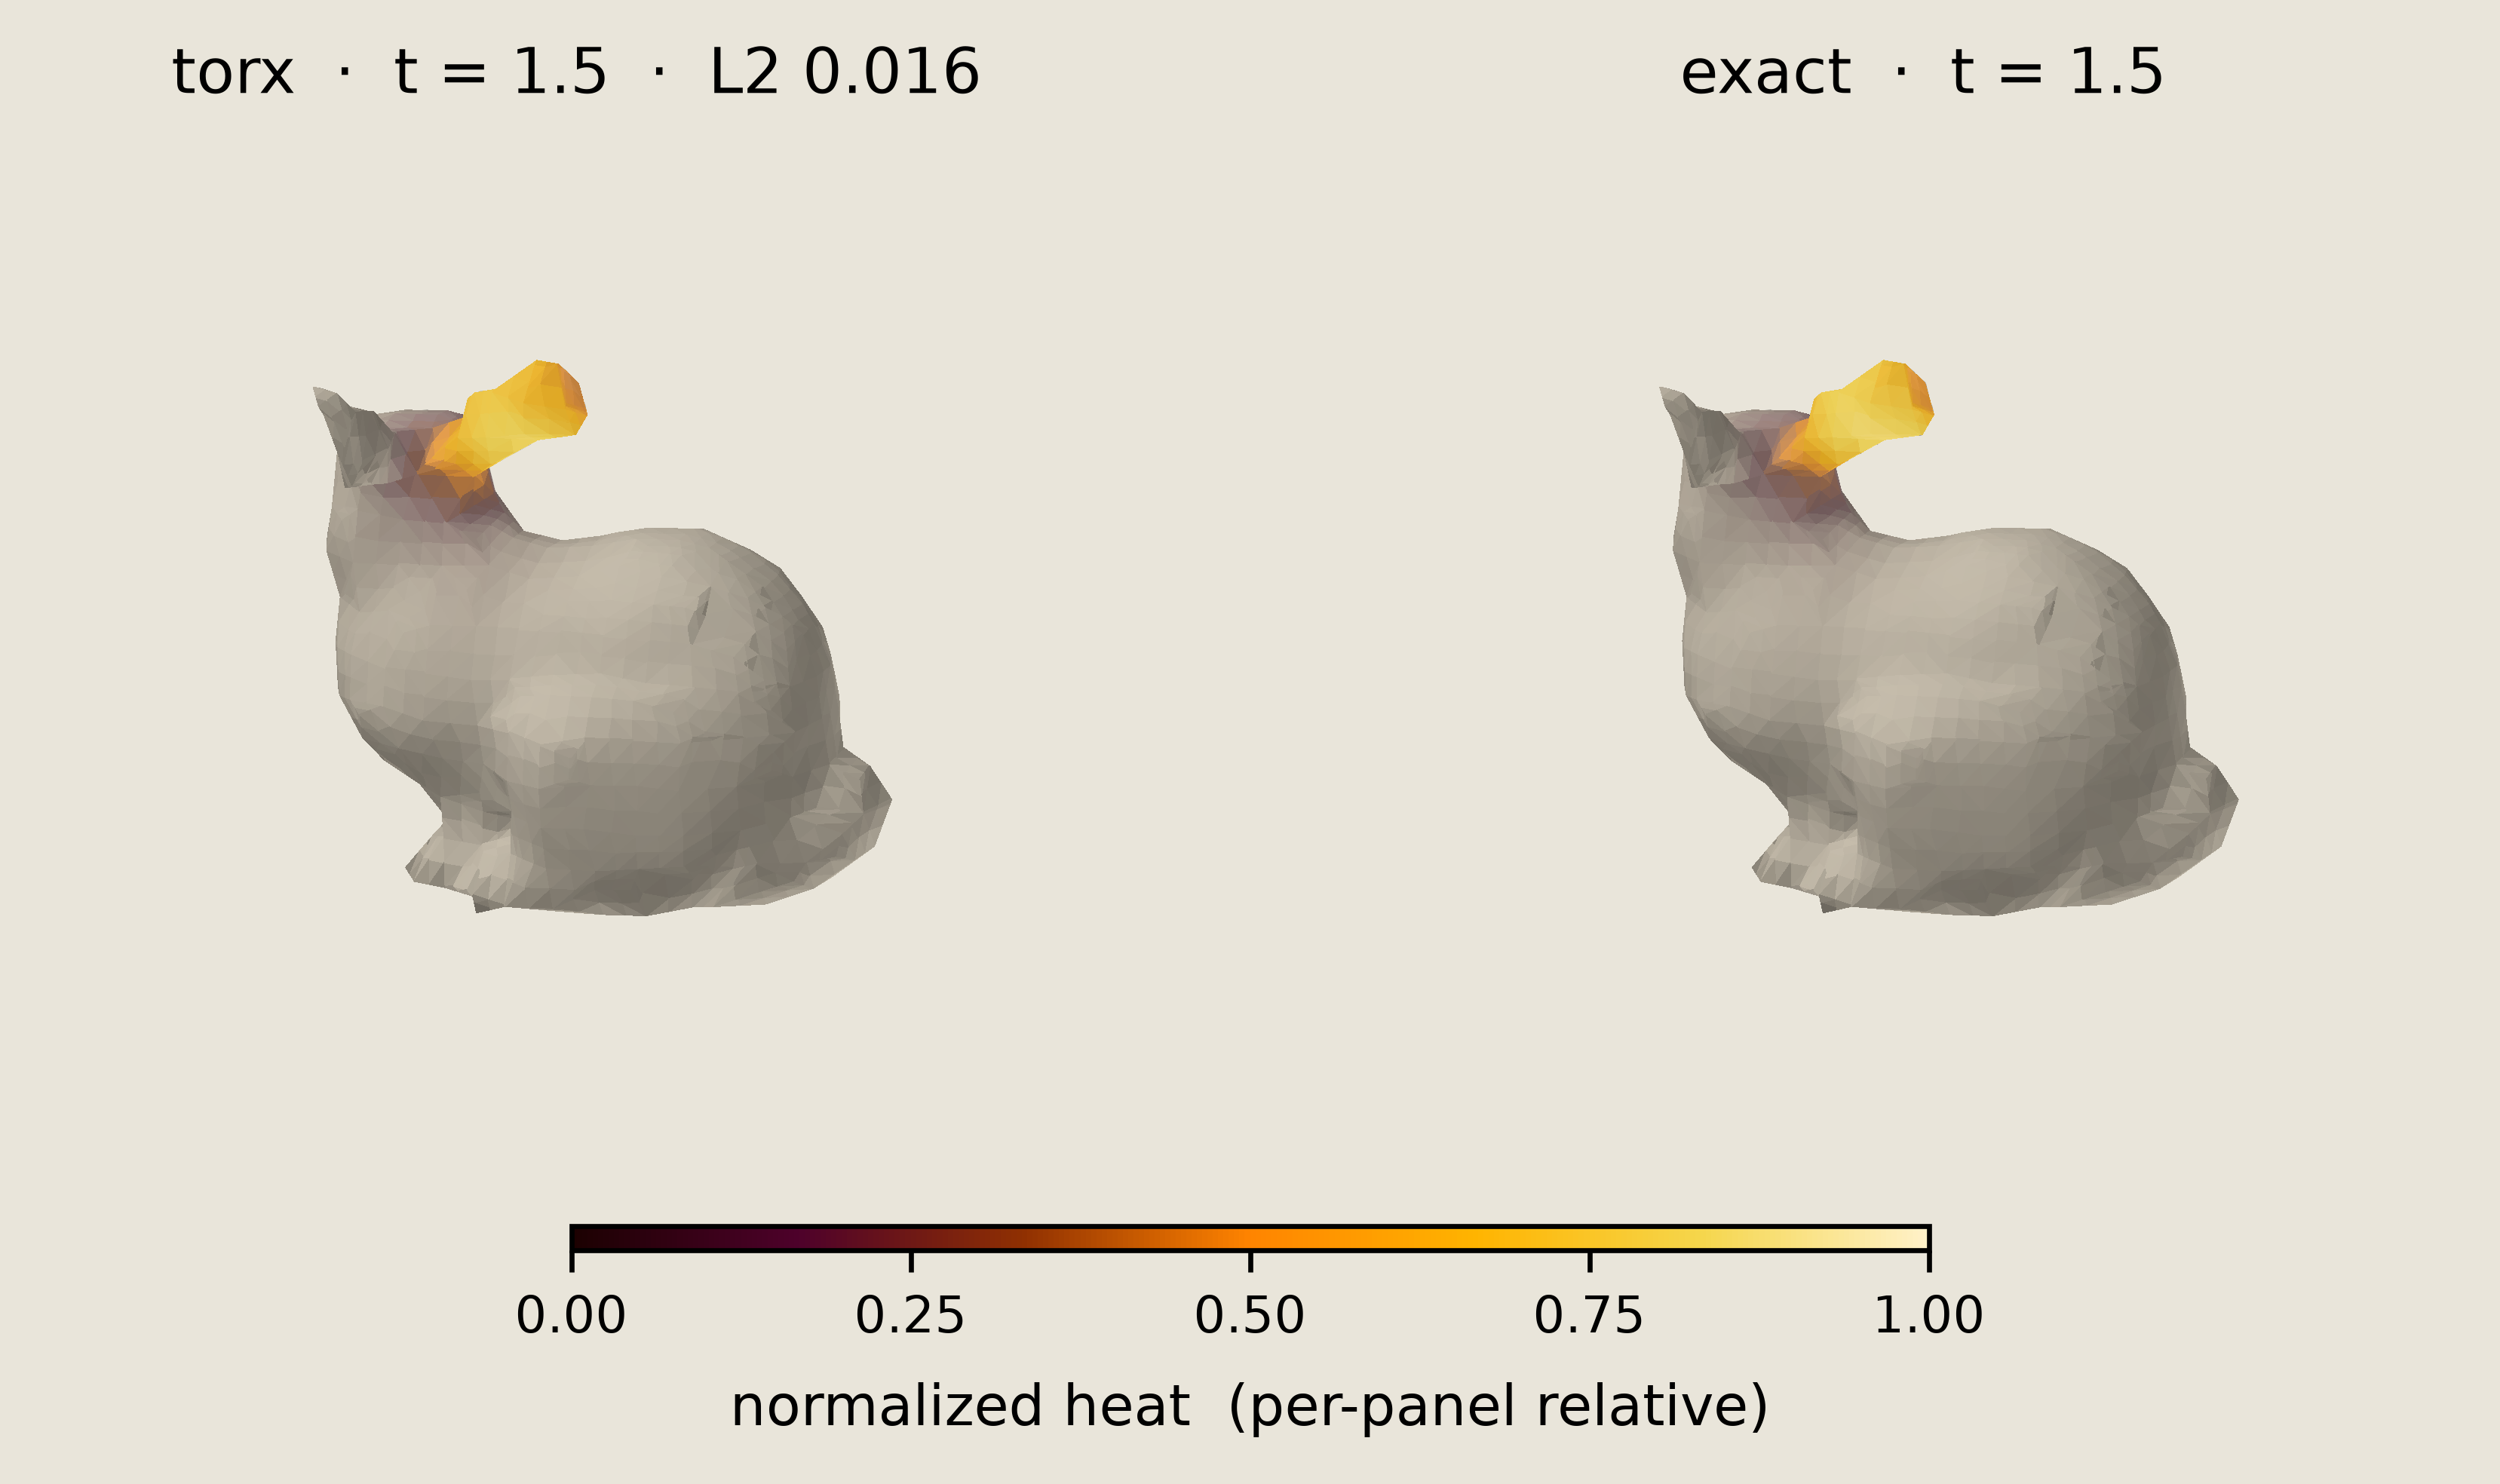

In [14]:
save_torx_reference_figure(
    vertices,
    faces,
    panels=[
        (f"torx  ·  t = {TORX_TIME:g}  ·  L2 {torx_l2:.3f}", torx_field),
        (f"exact  ·  t = {reference_times[0]:g}", exact_fields[0]),
    ],
    output_stem=FIGURE_DIR / "03_bunny_graph_heat_flow",
    ncols=2,
)

At $t = 1.5$, the sampled and exact panels are visually close for this mesh and `TORX_STEPS`. The printed Monte Carlo scale separates sampling noise from the residual product-formula bias, and this agreement is specific to this short time and mesh resolution.

The exact time progression is easier to read as a left-to-right row.

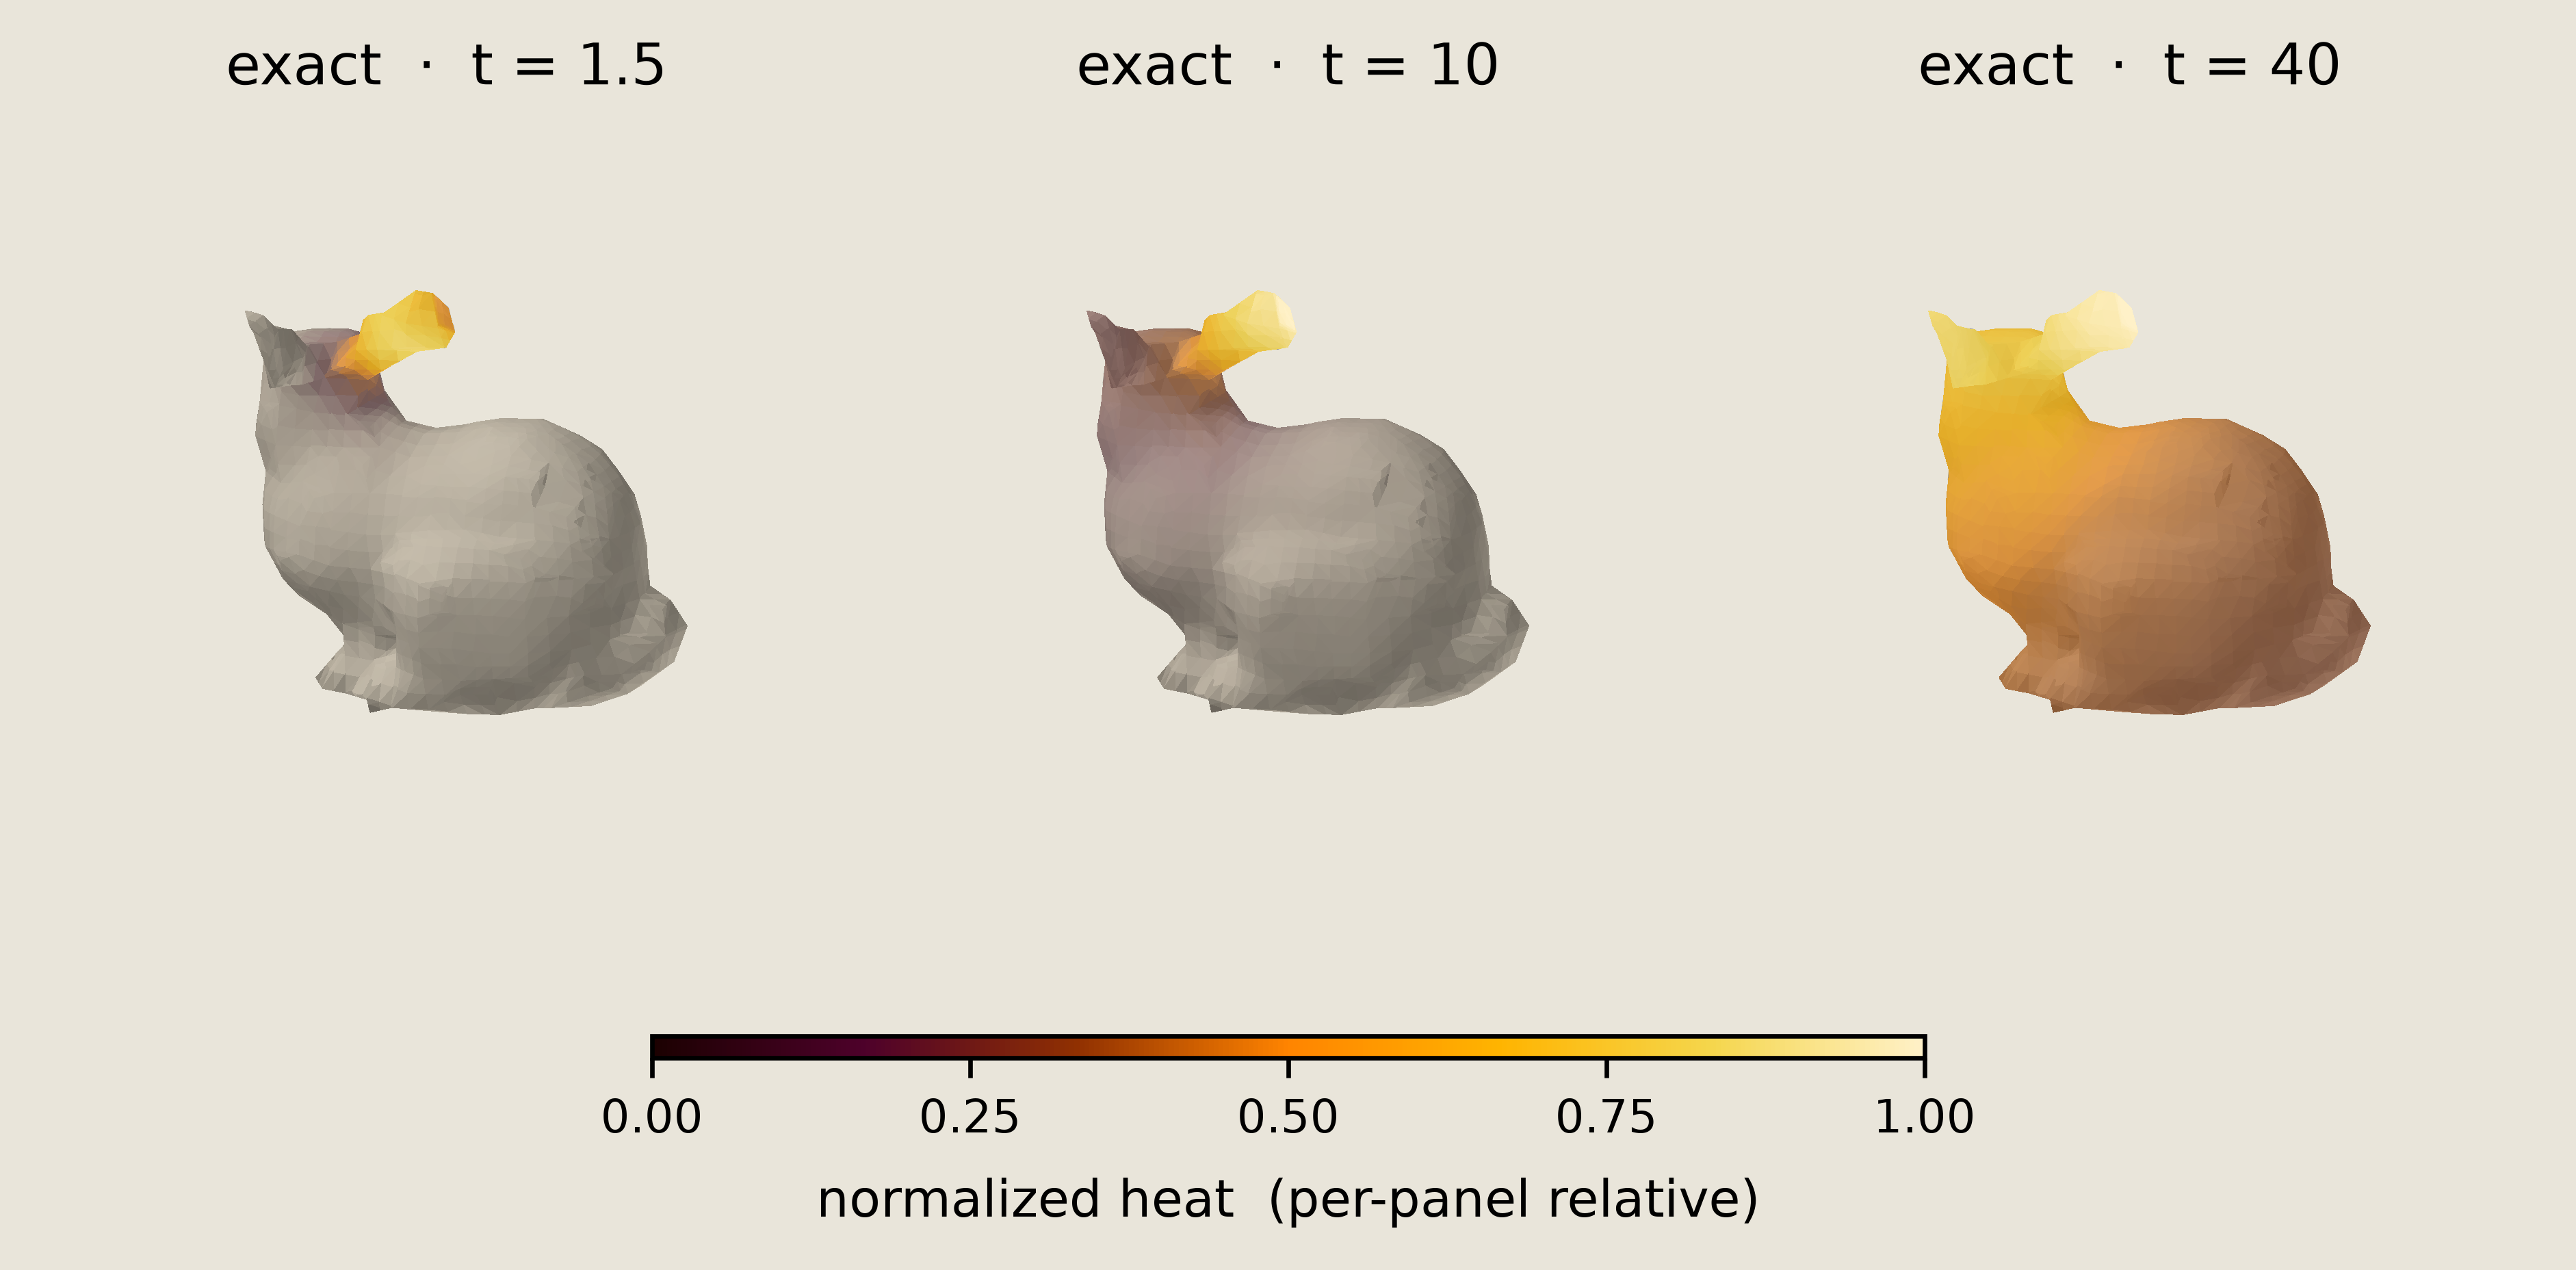

In [15]:
save_torx_reference_figure(
    vertices,
    faces,
    panels=[
        (f"exact  ·  t = {reference_times[0]:g}", exact_fields[0]),
        (f"exact  ·  t = {reference_times[1]:g}", exact_fields[1]),
        (f"exact  ·  t = {reference_times[2]:g}", exact_fields[2]),
    ],
    output_stem=FIGURE_DIR / "03_bunny_reference_diffusion",
    ncols=3,
)

With each panel normalized to its own peak, the $t = 40$ panel shows the exact front working its way across the back of the bunny, while the spread at $t = 10$ stays subtle.

## The same primitive, checked on a patch

Every mesh edge contributes exactly one `PSWAP`, identical to [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb), just more of them.

The full circuit has one gate per edge, which is too many to draw. Instead, we show the primitive on its own: a single symmetric swap on two adjacent vertices.

We build the structural two-pbit `PSWAP` circuit; the gate carries only its two sites, and the swap probability enters later as its theta.

In [16]:
example_pswap = DiscretePCircuit([PSWAP([0, 1])])

Here is the single-edge gate.

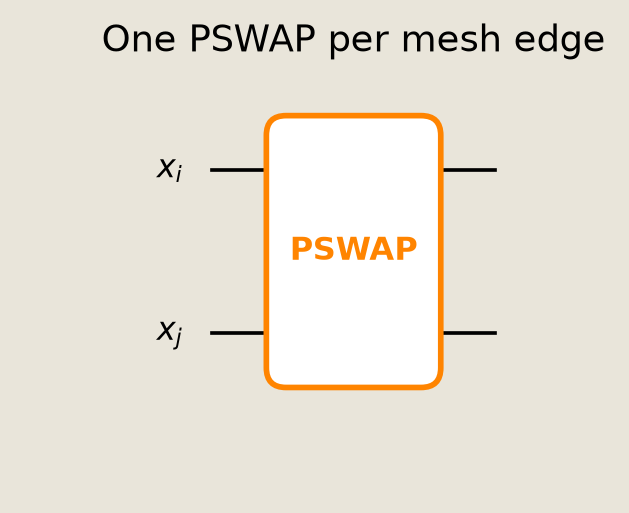

In [17]:
fig = P_sch.draw_edge_pswap(example_pswap)
savefig(fig, "03_bunny_pswap_circuit")

The circuit diagram shows the two-pbit gate that is repeated once per mesh edge in each Trotter layer.

We compare the Torx sampler with the deterministic mean of the same ordered product-formula sweep on the patch. This is a finite-sample agreement check with one seed and a fixed sample count; the comparison against the exact heat kernel happened on the full mesh above.

We grow a connected 32-vertex breadth-first search (BFS) patch around the same `source` vertex. We set the per-edge swap probability to `0.12`, essentially the full-mesh per-edge probability `p_edge` rounded, chosen so the walker fans out visibly over a few reps.

We then run the same ordered per-edge circuit on the patch and compare each sampled occupancy with the deterministic mean for those same edge updates.

In [18]:
PATCH_SIZE = 32
SWAP_PROBABILITY = 0.12
PATCH_REPS = 3



In [19]:
# BFS from source to extract a connected patch.
adjacency = [[] for _ in range(len(vertices))]
for a, b in edges:
    adjacency[int(a)].append(int(b))
    adjacency[int(b)].append(int(a))



In [20]:
seen = {int(source)}
queue = deque([int(source)])
while queue and len(seen) < PATCH_SIZE:
    node = queue.popleft()
    for neighbor in sorted(adjacency[node]):
        if neighbor not in seen:
            seen.add(neighbor)
            queue.append(neighbor)
            if len(seen) >= PATCH_SIZE:
                break



In [21]:
patch_vertices = sorted(seen)
patch_index = {old: new for new, old in enumerate(patch_vertices)}
patch_edges = np.asarray(
    [
        (patch_index[int(a)], patch_index[int(b)])
        for a, b in edges
        if int(a) in patch_index and int(b) in patch_index
    ],
    dtype=np.int32,
)
ordered_patch_edges = tuple((int(a), int(b)) for a, b in patch_edges)



In [22]:
print(
    f"patch: {len(patch_vertices)} vertices, {len(ordered_patch_edges)} internal edges, {PATCH_REPS} reps"
)
print(f"swap probability per edge: {SWAP_PROBABILITY}")

patch: 32 vertices, 84 internal edges, 3 reps
swap probability per edge: 0.12


For the deterministic patch reference, we apply the same expected edge update in the same order as the circuit. That order matters: the reference and `sample_pswap_product_formula` both consume `ordered_patch_edges`, so the deterministic mean matches the sampled PSWAP sweep being tested.

In [23]:
def deterministic_patch_reference(initial, patch_edges, reps, swap_probability):
    """Exact mean of the sequential ordered patch circuit."""
    deterministic = initial.copy()
    for _ in range(reps):
        for a, b in patch_edges:
            left, right = deterministic[a], deterministic[b]
            deterministic[a] = (
                1.0 - swap_probability
            ) * left + swap_probability * right
            deterministic[b] = (
                swap_probability * left + (1.0 - swap_probability) * right
            )
    return deterministic

In [24]:
patch_initial = np.zeros(len(patch_vertices), dtype=float)
patch_initial[patch_index[int(source)]] = 1.0

deterministic_patch = deterministic_patch_reference(
    patch_initial,
    ordered_patch_edges,
    PATCH_REPS,
    SWAP_PROBABILITY,
)

The `sample_pswap_product_formula` helper builds the ordered per-edge `PSWAP` circuit for the patch and estimates each vertex occupancy from Torx samples.

In [25]:
torx_patch = sample_pswap_product_formula(
    patch_initial,
    ordered_patch_edges,
    reps=PATCH_REPS,
    swap_probability=SWAP_PROBABILITY,
    num_samples=4_000,
    seed=17,
)
patch_l2 = float(np.linalg.norm(torx_patch - deterministic_patch))

print(f"Torx vs deterministic ordered-sweep mean L2 error: {patch_l2:.4f}")

Torx vs deterministic ordered-sweep mean L2 error: 0.0159


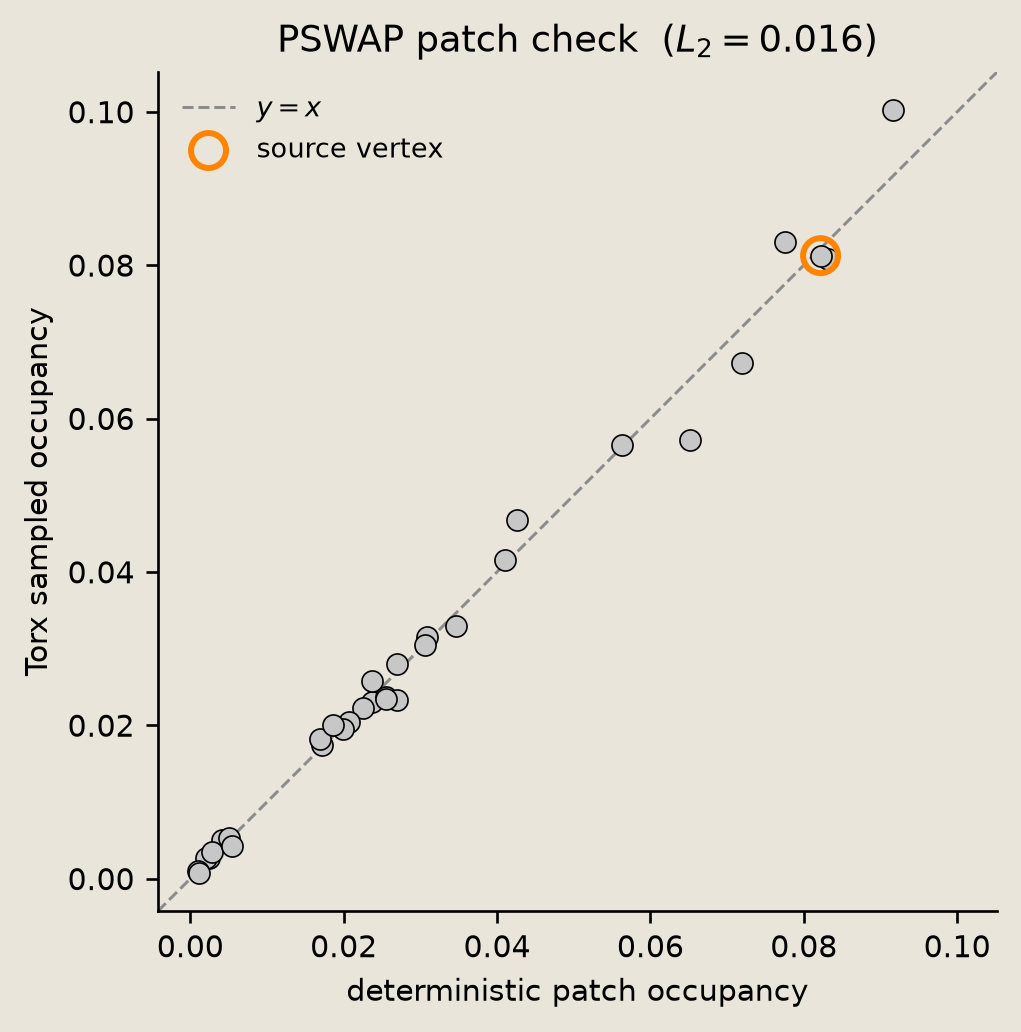

In [26]:
np.testing.assert_allclose(torx_patch.sum(), 1.0, atol=5e-3)
assert patch_l2 < 0.04

# Convert the global source index to its local patch index for plotting.
source_local = patch_index[int(source)]
fig = P_samp.patch_parity_figure(
    deterministic_patch,
    torx_patch,
    source_index=source_local,
    l2_error=patch_l2,
)
savefig(fig, "03_bunny_torx_patch_check")

The scatter plot shows vertex-by-vertex agreement between the sampled patch occupancies and the deterministic mean of the same ordered product-formula sweep. The orange-ringed point is the `source` vertex.

## Conclusion

We applied graph heat diffusion to the surface of the Stanford bunny, using one `PSWAP` per mesh edge.

- The mesh is the graph, each vertex is a pbit, and its Laplacian $L = D - A$ gives the heat equation $\dot x = -Lx$.
- The Laplacian splits into one two-node term per edge, so one mesh edge maps to one `PSWAP`, and the Torx sampler diffuses the surface without forming $e^{-Lt}$ (the exact references use dense linear algebra only for comparison).
- Torx sampled the heat field on this full coarse mesh at $t = 1.5$ and matched the exact kernel to $L_2 < 0.04$ for the chosen `TORX_STEPS`. The exact reference carries the longer-time spread because sampling those times would need many more Trotter layers.
- A 32-vertex patch checks seeded finite-sample agreement against the deterministic mean of the same ordered sweep.

For further experiments, raise `PATCH_REPS` to fan the walker out across more of the surface, or replace the bunny with another mesh and retune the step count and error threshold.

See also:

- [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb), the same construction on small graphs.
- [`04_execution_interface_readouts.ipynb`](04_execution_interface_readouts.ipynb), how `SampleSimulator` turns a circuit into samples.

## References

1. Trotter, H.F. 1959. [*On the product of semi-groups of operators*](https://www.ams.org/journals/proc/1959-010-04/S0002-9939-1959-0108732-6/). Proc. Amer. Math. Soc. 10(4), 545-551. The classical product formula behind the ordered per-edge sweep reused here.

